Primero, instalaremos las librerías necesarias: `FastAPI` para crear la API y `uvicorn` para ejecutar el servidor web.

In [1]:
!pip install fastapi uvicorn python-multipart nest_asyncio pyngrok SpeechRecognition pydub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.9/32.9 MB 39.2 MB/s eta 0:00:00


Ahora, definiremos la aplicación FastAPI con los dos endpoints. El endpoint `document/search/byText` aceptará una cadena de texto en el cuerpo de la solicitud (JSON), y `document/search/byVoice` aceptará un archivo de audio como parte de un formulario multipart. En este ejemplo, los endpoints solo devolverán un mensaje de confirmación, pero aquí es donde integrarías tu lógica de búsqueda real.

In [2]:
from fastapi._compat.v2 import normalize_name
from fastapi import FastAPI, UploadFile, File
from pydantic import BaseModel
import uvicorn
import nest_asyncio
import speech_recognition as sr
from pydub import AudioSegment
import os
import warnings
import re
import unicodedata

# Ignorar los SyntaxWarning de pydub en Python 3.12+
warnings.filterwarnings("ignore", category=SyntaxWarning, module="pydub")

# Aplicar nest_asyncio para permitir la ejecución de uvicorn en un entorno como Colab
nest_asyncio.apply()

app = FastAPI(
    title="API de Búsqueda de Documentos",
    description="API para buscar documentos por texto o voz."
)

LEET_MAP = {
    "0": "o",
    "1": "i",
    "3": "e",
    "4": "a",
    "5": "s",
    "7": "t"
}

MESES = {
    "enero": "01",
    "febrero": "02",
    "marzo": "03",
    "abril": "04",
    "mayo": "05",
    "junio": "06",
    "julio": "07",
    "agosto": "08",
    "septiembre": "09",
    "setiembre": "09",
    "octubre": "10",
    "noviembre": "11",
    "diciembre": "12"
}

NUMEROS_TEXTO = {
    "uno": "1", "dos": "2", "tres": "3", "cuatro": "4", "cinco": "5",
    "seis": "6", "siete": "7", "ocho": "8", "nueve": "9", "diez": "10"
}

# Modelo para la entrada de texto
class TextQuery(BaseModel):
    text: str

def remove_accents(text: str) -> str:
    return ''.join(
        c for c in unicodedata.normalize('NFD', text)
        if unicodedata.category(c) != 'Mn'
    )

def tokenize(text: str):
    return re.findall(r'\d{4}-\d{2}-\d{2}|\w+', text)

def normalize_numbers(text: str) -> str:
    for word, num in NUMEROS_TEXTO.items():
        text = re.sub(rf'\b{word}\b', num, text)
    return text

#filtro leet speak
def normalize_leet_safe(text: str) -> str:
    tokens = tokenize(text)
    new_tokens = []

    for token in tokens:
        # si es fecha → no tocar
        if re.match(r'\d{4}-\d{2}-\d{2}', token):
            new_tokens.append(token)
            continue

        # aplicar leet solo a texto
        new_token = ''.join(LEET_MAP.get(c, c) for c in token)
        new_tokens.append(new_token)

    return ' '.join(new_tokens)

def protect_dates(text: str):
    dates = re.findall(r'\d{4}-\d{2}-\d{2}', text)
    replacements = {}

    for i, d in enumerate(dates):
        key = f"__DATE{i}__"
        replacements[key] = d
        text = text.replace(d, key)

    return text, replacements

def normalize_dates(text: str) -> str:
    # formato completo: 1 de enero del 2026
    pattern_full = re.compile(r'\b(\d{1,2}) de (\w+) del (\d{4})\b')

    def repl_full(match):
        day = int(match.group(1))
        month = MESES.get(match.group(2), "01")
        year = match.group(3)
        return f"{year}-{month}-{day:02d}"

    text = pattern_full.sub(repl_full, text)

    # formato mes-año: marzo del 2026
    pattern_month = re.compile(r'\b(\w+) del (\d{4})\b')

    def repl_month(match):
        month = MESES.get(match.group(1), None)
        if month:
            return f"{match.group(2)}-{month}"
        return match.group(0)

    text = pattern_month.sub(repl_month, text)

    return text


def restore_dates(text: str, replacements: dict):
    for key, value in replacements.items():
        text = text.replace(key, value)
    return text


def remove_repeated_chars(text: str) -> str:
    # reduce repeticiones largas → "yaaaaa" → "ya"
    return re.sub(r'(.)\1{2,}', r'\1', text)


def clean_special_chars(text: str) -> str:
    # elimina todo excepto letras, numeros y espacios
    return re.sub(r'[^a-z0-9\s-]', '', text)

def convert_audio_to_wav(input_path: str, output_path: str) -> str:
    """Convierte un archivo de audio a formato WAV usando pydub."""
    audio = AudioSegment.from_file(input_path)
    audio.export(output_path, format="wav")
    return output_path

#Pipeline de normalizacion textual - limpieza de entrada
def normalize_content(content: str) -> str:
    if not content:
        return ""

    text = content.lower()

    # quitar acentos
    text = ''.join(
        c for c in unicodedata.normalize('NFD', text)
        if unicodedata.category(c) != 'Mn'
    )

    # normalizar fechas primero
    text = normalize_dates(text)

    # tokenizar correctamente
    tokens = re.findall(r'\d{4}-\d{2}-\d{2}|\w+', text)

    normalized_tokens = []

    for token in tokens:
        # si es fecha → mantener
        if re.match(r'\d{4}-\d{2}-\d{2}', token):
            normalized_tokens.append(token)
            continue

        # leet safe
        token = ''.join(LEET_MAP.get(c, c) for c in token)

        # numeros en texto
        for word, num in NUMEROS_TEXTO.items():
            token = re.sub(rf'\b{word}\b', num, token)

        # remover repeticiones
        token = re.sub(r'(.)\1{2,}', r'\1', token)

        # limpiar caracteres raros
        token = re.sub(r'[^a-z0-9]', '', token)

        if token:
            normalized_tokens.append(token)

    return ' '.join(normalized_tokens)

def processVoiceWithGoogleApi(file_path: str) -> str:
    """Procesa un archivo de audio usando la API de Google (a través de SpeechRecognition)."""
    recognizer = sr.Recognizer()
    try:
        # SpeechRecognition soporta formatos como WAV, AIFF, FLAC de forma nativa
        with sr.AudioFile(file_path) as source:
            audio_data = recognizer.record(source)
            # Transcribir usando Google Web Speech API (gratuito, para pruebas)
            text = recognizer.recognize_google(audio_data, language="es-ES")
            return text
    except sr.UnknownValueError:
        return "No se pudo entender el audio"
    except sr.RequestError as e:
        return f"Error al conectarse a la API de Google; {e}"
    except Exception as e:
        return f"Error procesando el audio: {str(e)}"

@app.post("/document/search/byText")
async def search_by_text(query: TextQuery):
    """Busca documentos basándose en una cadena de texto."""
    print(f"Recibida solicitud de búsqueda por texto: {query.text}")

    # Pre procesamiento de texto usando la función normalize_content
    normalized_text = normalize_content(query.text)

    # Aquí iría tu lógica para buscar por texto
    return {"message": normalized_text, "query": query.text, "results": []}

@app.post("/document/search/byVoice")
async def search_by_voice(audio_file: UploadFile = File(...)):
    """Busca documentos basándose en un archivo de audio."""
    print(f"Recibida solicitud de búsqueda por voz: {audio_file.filename}")

    # Guardar el archivo temporalmente para procesarlo
    original_file_location = f"/tmp/{audio_file.filename}"
    with open(original_file_location, "wb") as file_object:
        file_object.write(audio_file.file.read())

    # Convertir el archivo a WAV
    wav_file_location = f"/tmp/converted_{audio_file.filename}.wav"
    try:
        convert_audio_to_wav(original_file_location, wav_file_location)
    except Exception as e:
        return {"message": f"Error al convertir el audio a WAV: {str(e)}", "filename": audio_file.filename, "results": []}

    # Procesar el audio a texto
    transcription = processVoiceWithGoogleApi(wav_file_location)

    # Pre procesamiento de texto como resultado de Modulo 1
    transcription = normalize_content(transcription)

    # Aquí iría tu lógica de búsqueda usando la transcripción

    return {"message": transcription, "filename": audio_file.filename, "size": audio_file.size, "results": []}


/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


Para ejecutar la API en Colab y poder acceder a ella desde fuera, podemos usar `uvicorn` junto con `pyngrok` (para crear un túnel público). Ejecuta la siguiente celda y se te proporcionará una URL pública.

In [3]:
from pyngrok import ngrok
import os
import uvicorn
import threading

# Cierra cualquier túnel ngrok existente para evitar conflictos
ngrok.kill()

# --- CONFIGURACIÓN DE NGROK ---
# Ngrok requiere un authtoken para funcionar.
# 1. Regístrate gratis en: https://dashboard.ngrok.com/signup
# 2. Copia tu authtoken desde: https://dashboard.ngrok.com/get-started/your-authtoken
# 3. Pega tu authtoken aquí abajo reemplazando 'TU_TOKEN_AQUI'
#ngrok_auth_token = "3C6RbXVl84G8wT75IufyBXPhwv2_3moCnsaWpVueFRL9g8AsR"
ngrok_auth_token = "3C6RbXVl84G8wT75IufyBXPhwv2_3moCnsaWpVueFRL9g8AsR"

if ngrok_auth_token != "TU_TOKEN_AQUI":
    ngrok.set_auth_token(ngrok_auth_token)

    # Iniciar el túnel ngrok
    try:
        public_url = ngrok.connect(8000)
        print(f"Tu API pública está disponible en: {public_url}")
        print("Accede a la documentación interactiva (Swagger UI) en:")
        print(f"{public_url}/docs")

        # Ejecutar Uvicorn en un hilo separado para no bloquear Colab
        def run_uvicorn():
            uvicorn.run(app, host="0.0.0.0", port=8000)

        uvicorn_thread = threading.Thread(target=run_uvicorn)
        uvicorn_thread.start()
    except Exception as e:
        print(f"Error al iniciar ngrok: {e}")
else:
    print("Por favor, actualiza la variable 'ngrok_auth_token' con tu token real de ngrok.")


Tu API pública está disponible en: NgrokTunnel: "https://transitory-shawnta-sinistrally.ngrok-free.dev" -> "http://localhost:8000"
Accede a la documentación interactiva (Swagger UI) en:
NgrokTunnel: "https://transitory-shawnta-sinistrally.ngrok-free.dev" -> "http://localhost:8000"/docs


Una vez que la celda anterior haya terminado de ejecutarse y te muestre la URL pública de ngrok, puedes probar tus endpoints.

**Ejemplo para `document/search/byText` (usando `curl` o cualquier cliente HTTP):**

```bash
curl -X POST -H "Content-Type: application/json" -d '{"text": "El Imperio Galáctico"}' "TU_URL_NGROK/document/search/byText"
```

**Ejemplo para `document/search/byVoice` (necesitarías un archivo de audio, por ejemplo, `audio.wav`):**

```bash
curl -X POST -F "audio_file=@/path/to/your/audio.wav" "TU_URL_NGROK/document/search/byVoice"
```

Recuerda reemplazar `TU_URL_NGROK` con la URL que te proporciona la salida de la celda anterior. También puedes usar la interfaz de Swagger UI visitando `TU_URL_NGROK/docs` para probar los endpoints directamente desde tu navegador.

## Módulo de Limpieza y Normalización de Documentación

Este bloque de código se encarga de descargar documentación desde repositorios crudos, limpiar el texto, aplicar reglas heurísticas y usar TF-IDF para eliminar duplicados semánticos.

In [4]:
import re
import requests
import unicodedata
import os
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# URLs RAW
TECHNICAL_DOC_URL = "https://raw.githubusercontent.com/diegoarambulo/PROYECTO_TITULACION_GRUPO_1/main/manuales%20de%20sistema/legibles/DOCUMENTACION_TECNICA_API_V1.md"
USER_DOC_URL = "https://raw.githubusercontent.com/diegoarambulo/PROYECTO_TITULACION_GRUPO_1/main/manuales%20de%20sistema/legibles/DOCUMENTACION_USUARIO_WEB_V1.md"

def normalize_accents(text: str) -> str:
    """Elimina tildes y marcas diacríticas."""
    return ''.join(
        c for c in unicodedata.normalize('NFD', text)
        if unicodedata.category(c) != 'Mn'
    )

def remove_nonsense_words(text: str) -> str:
    """Elimina palabras sin sentido (ej. con letras repetidas más de 3 veces consecutivas)."""
    text = re.sub(r'\b\w*([a-zA-Z])\1{2,}\w*\b', '', text)
    return text

def remove_images(text: str) -> str:
    """Elimina etiquetas de imágenes en formato Markdown."""
    return re.sub(r'!\[.*?\]\(.*?\)', '', text)

def clean_garbage_characters(text: str) -> str:
    """Elimina cadenas de caracteres especiales basura."""
    # Elimina bloques de 5 o más símbolos repetidos o mezclados que sean ruido
    return re.sub(r'[@#\$%\^&\*\(\)\[\]{};:]{5,}', '', text)

def remove_consecutive_duplicates(text: str) -> str:
    """Elimina líneas repetidas consecutivamente."""
    lines = text.split('\n')
    result = []
    prev_line = None

    for line in lines:
        stripped = line.strip()
        # Mantener líneas vacías para conservar el formato original
        if not stripped:
            result.append(line)
            continue

        if stripped != prev_line:
            result.append(line)
            prev_line = stripped

    return '\n'.join(result)

def filter_by_semantic_relevance(text: str, doc_type: str) -> str:
    """Filtra párrafos que no tienen relevancia semántica con el objetivo del manual."""
    target_topics = {
        "technical": "api endpoint json request response get post autenticacion servidor parametros busqueda codigo programacion estructura payload",
        "user": "manual usuario plataforma web interfaz menu botones navegacion gestion documentos consulta registro sistema"
    }

    target_topic = target_topics.get(doc_type, "")
    paragraphs = [p.strip() for p in text.split('\n\n') if p.strip()]

    if not paragraphs:
        return text

    vectorizer = TfidfVectorizer()
    corpus = [target_topic] + paragraphs

    try:
        tfidf_matrix = vectorizer.fit_transform(corpus)
    except ValueError:
        return text

    cosine_sim = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:]).flatten()

    filtered_paragraphs = []
    threshold = 0.02

    for i, sim in enumerate(cosine_sim):
        para = paragraphs[i]
        # Conservar estructuras técnicas importantes (código, json, tablas)
        is_technical_structure = '```' in para or ('{' in para and '}' in para) or '|' in para

        if sim > threshold or len(para.split()) < 15 or is_technical_structure:
            filtered_paragraphs.append(para)

    return '\n\n'.join(filtered_paragraphs)

# ----------------------------
# PIPELINE PRINCIPAL
# ----------------------------
def purge_documentation_v2():
    docs = {
        "technical": TECHNICAL_DOC_URL,
        "user": USER_DOC_URL
    }

    results = {}

    for name, url in docs.items():
        response = requests.get(url)
        original_text = response.text

        # 1. Normalizar tildes
        cleaned_text = normalize_accents(original_text)

        # 2. Convertir a minúsculas
        cleaned_text = cleaned_text.lower()

        # 3. Eliminar imágenes Markdown
        cleaned_text = remove_images(cleaned_text)

        # 4. Limpiar basura de caracteres especiales
        cleaned_text = clean_garbage_characters(cleaned_text)

        # 5. Limpiar palabras sin sentido
        cleaned_text = remove_nonsense_words(cleaned_text)

        # 6. Filtrado semántico de temas irrelevantes
        cleaned_text = filter_by_semantic_relevance(cleaned_text, name)

        # 7. Eliminar líneas duplicadas consecutivas
        cleaned_text = remove_consecutive_duplicates(cleaned_text)

        results[name] = {
            "original_length": len(original_text),
            "cleaned_length": len(cleaned_text),
            "cleaned_text": cleaned_text
        }

        # Exportar a archivo local en Colab
        output_filename = f"manual_{name}_limpio.md"
        with open(output_filename, "w", encoding="utf-8") as f:
            f.write(cleaned_text)
        print(f"Manual guardado exitosamente: {output_filename}")

    return results


INFO:     Started server process [4822]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


In [5]:
#PROCESAMIENTO POR LOTES PIPELINA PARA CRUZAR INFORMACION DEL DATASET CONTRA TRANSCRIPCION DIRECTA DE LOS AUDIOS Y CALCULAR VALORES
#DE CONFIANZA

#Para generar los nuevos manuales purgados ejecutar la seccion de visualizacion de los manuales

import requests
import json
import difflib
import os
from collections import Counter

# Descargar y procesar el archivo JSON una sola vez
json_url = "https://raw.githubusercontent.com/diegoarambulo/PROYECTO_TITULACION_GRUPO_1/main/semana%202/fase%20de%20preparacion%20y%20procesamiento%20de%20datos/transcripcionesXindice.json"
response_json = requests.get(json_url)
json_data = response_json.json()

print("Iniciando procesamiento por lotes (001 al 060)...\n")

resultados_texto = []
resultados_intencion = []
resultados_combinados = []
intenciones_list = []

def detectar_intencion(texto: str) -> str:
    """
    Función heurística mejorada para detectar la intención basada en palabras clave.
    """
    texto = texto.lower()

    # Palabras clave ampliadas para descarga
    kw_descarga = ["descarg", "bajar", "bajame", "exportar", "guardar", "obtener"]

    # Palabras clave ampliadas para navegación
    kw_navegacion = ["donde", "menu", "como puedo", "opcion", "parte del sistema", "navegar", "ir a", "acceder", "pantalla", "seccion", "redirigir"]

    if any(palabra in texto for palabra in kw_descarga):
        return "descarga de documento"
    elif any(palabra in texto for palabra in kw_navegacion):
        return "navegación"
    else:
        return "listar documentos"

for i in range(1, 61):
    idx = f"{i:03d}"
    audio_url = f"https://raw.githubusercontent.com/diegoarambulo/PROYECTO_TITULACION_GRUPO_1/main/semana%202/fase%20de%20preparacion%20y%20procesamiento%20de%20datos/audios/{idx}.wav"
    audio_path = f"/tmp/{idx}.wav"
    clean_wav_path = f"/tmp/{idx}_clean.wav"

    # Descargar el archivo de audio
    response_audio = requests.get(audio_url)
    if response_audio.status_code != 200:
        print(f"[{idx}] Error al descargar el audio desde la URL.")
        continue

    with open(audio_path, 'wb') as f:
        f.write(response_audio.content)

    # Obtener el texto esperado y la intención
    try:
        orden_data = json_data["dataSetOrdenes"][idx]
        texto_esperado = orden_data["texto"]
        intencion_id = str(orden_data.get("intencion", "Desconocida"))
    except KeyError:
        print(f"[{idx}] Error al buscar la clave en el JSON.")
        texto_esperado = None

    if texto_esperado:
        # Mapear la intención usando el catálogo si es posible
        intencion_nombre = json_data.get("catalogos", {}).get("intenciones", {}).get(intencion_id, intencion_id)
        intenciones_list.append(intencion_nombre)

        try:
            # Limpiar/Estandarizar el formato del audio usando pydub
            convert_audio_to_wav(audio_path, clean_wav_path)

            # Transcribir el audio estandarizado
            transcripcion = processVoiceWithGoogleApi(clean_wav_path)

            # Normalizar ambos textos
            texto_esperado_norm = normalize_content(texto_esperado)
            transcripcion_norm = normalize_content(transcripcion)

            # Calcular el porcentaje de similitud (confianza de texto)
            similitud = difflib.SequenceMatcher(None, texto_esperado_norm, transcripcion_norm).ratio()
            porcentaje_texto = similitud * 100

            # Detectar intención y calcular confianza de intención
            intencion_detectada = detectar_intencion(transcripcion_norm)
            porcentaje_intencion = 100.0 if intencion_detectada == intencion_nombre else 0.0

            # Indicador de confianza combinado (promedio)
            confianza_total = (porcentaje_texto + porcentaje_intencion) / 2

            print(f"[{idx}] Confianza Total: {confianza_total:6.2f}% | Texto: {porcentaje_texto:6.2f}% | Intención: {intencion_detectada} (Esp: {intencion_nombre})")

            resultados_texto.append(porcentaje_texto)
            resultados_intencion.append(porcentaje_intencion)
            resultados_combinados.append(confianza_total)
        except Exception as e:
            print(f"[{idx}] Error durante el procesamiento: {e}")
    else:
        print(f"[{idx}] No se pudo completar la verificación por falta de texto esperado.")

# Mostrar el resumen final
if resultados_combinados:
    promedio_texto = sum(resultados_texto) / len(resultados_texto)
    promedio_intencion = sum(resultados_intencion) / len(resultados_intencion)
    promedio_total = sum(resultados_combinados) / len(resultados_combinados)

    print("\n--- RESUMEN ---")
    print(f"Total procesados: {len(resultados_combinados)}")
    print(f"Confianza Promedio Texto:      {promedio_texto:.2f}%")
    print(f"Confianza Promedio Intención:  {promedio_intencion:.2f}%")
    print(f"Confianza Promedio GLOBAL:     {promedio_total:.2f}%")

    print("\n--- BALANCE DEL DATASET (INTENCIONES ESPERADAS) ---")
    conteo_intenciones = Counter(intenciones_list)
    total_intenciones = len(intenciones_list)
    for intencion, count in conteo_intenciones.most_common():
        porcentaje = (count / total_intenciones) * 100
        print(f"- {intencion}: {count} muestras ({porcentaje:.2f}%)")

Iniciando procesamiento por lotes (001 al 060)...

[001] Confianza Total:  50.00% | Texto: 100.00% | Intención: listar documentos (Esp: descarga de documento)
[002] Confianza Total: 100.00% | Texto: 100.00% | Intención: navegación (Esp: navegación)
[003] Confianza Total:  99.03% | Texto:  98.06% | Intención: listar documentos (Esp: listar documentos)
[004] Confianza Total:  99.44% | Texto:  98.88% | Intención: listar documentos (Esp: listar documentos)
[005] Confianza Total: 100.00% | Texto: 100.00% | Intención: navegación (Esp: navegación)
[006] Confianza Total:  98.10% | Texto:  96.20% | Intención: listar documentos (Esp: listar documentos)
[007] Confianza Total: 100.00% | Texto: 100.00% | Intención: listar documentos (Esp: listar documentos)
[008] Confianza Total:  99.24% | Texto:  98.48% | Intención: listar documentos (Esp: listar documentos)
[009] Confianza Total: 100.00% | Texto: 100.00% | Intención: listar documentos (Esp: listar documentos)
[010] Confianza Total: 100.00% | Text

## Seccion de linea grafica ================================ empieza aqui

Los siguientes elementos solo son para obtener las graficas informativas

In [7]:
#ELEMENTO GRAFICO DE GENERACION - NO OBLIGATORIO

results = purge_documentation_v2()

for doc_name, metrics in results.items():
    print(f"--- Resultados para: {doc_name} ---")

    orig = metrics.get('original_length', 0)
    clean = metrics.get('cleaned_length', 0)

    for key, value in metrics.items():
        if key != 'cleaned_text':
            print(f"{key}: {value}")

    if orig > 0:
        reduction = orig - clean
        pct = (reduction / orig) * 100
        print(f"caracteres_eliminados: {reduction}")
        print(f"reduccion_porcentaje: {pct:.2f}%")
    print("\n")

Manual guardado exitosamente: manual_technical_limpio.md
Manual guardado exitosamente: manual_user_limpio.md
--- Resultados para: technical ---
original_length: 9803
cleaned_length: 5719
caracteres_eliminados: 4084
reduccion_porcentaje: 41.66%


--- Resultados para: user ---
original_length: 8879
cleaned_length: 6094
caracteres_eliminados: 2785
reduccion_porcentaje: 31.37%




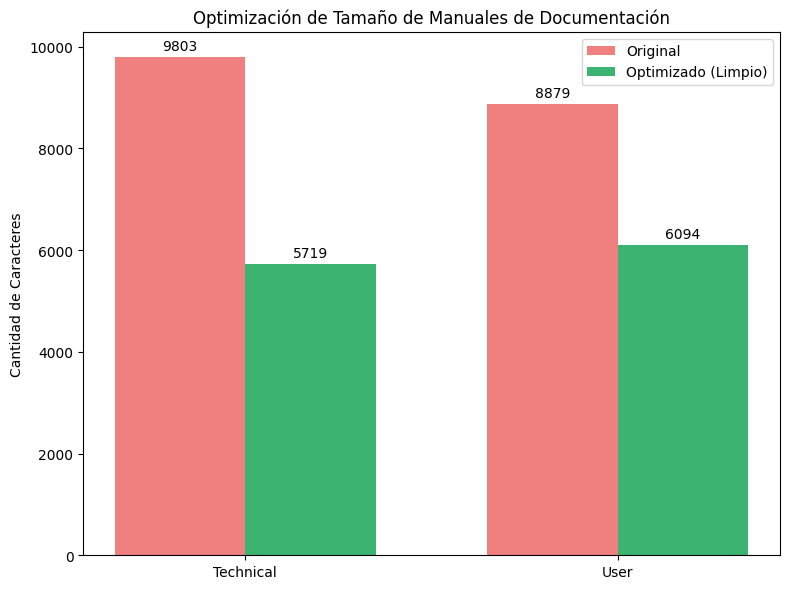

In [8]:
#ELEMENTO GRAFICO DE GENERACION - NO OBLIGATORIO

import matplotlib.pyplot as plt
import numpy as np

# Obtener las etiquetas (nombres de los manuales) y los datos de longitud
labels = list(results.keys())
original_lengths = [results[doc]['original_length'] for doc in labels]
cleaned_lengths = [results[doc]['cleaned_length'] for doc in labels]

x = np.arange(len(labels))  # la ubicación de las etiquetas
width = 0.35  # el ancho de las barras

fig, ax = plt.subplots(figsize=(8, 6))
rects1 = ax.bar(x - width/2, original_lengths, width, label='Original', color='lightcoral')
rects2 = ax.bar(x + width/2, cleaned_lengths, width, label='Optimizado (Limpio)', color='mediumseagreen')

# Añadir etiquetas, título y personalizar los ejes
ax.set_ylabel('Cantidad de Caracteres')
ax.set_title('Optimización de Tamaño de Manuales de Documentación')
ax.set_xticks(x)
ax.set_xticklabels([label.capitalize() for label in labels])
ax.legend()

# Añadir las cantidades sobre las barras
ax.bar_label(rects1, padding=3)
ax.bar_label(rects2, padding=3)

fig.tight_layout()
plt.show()

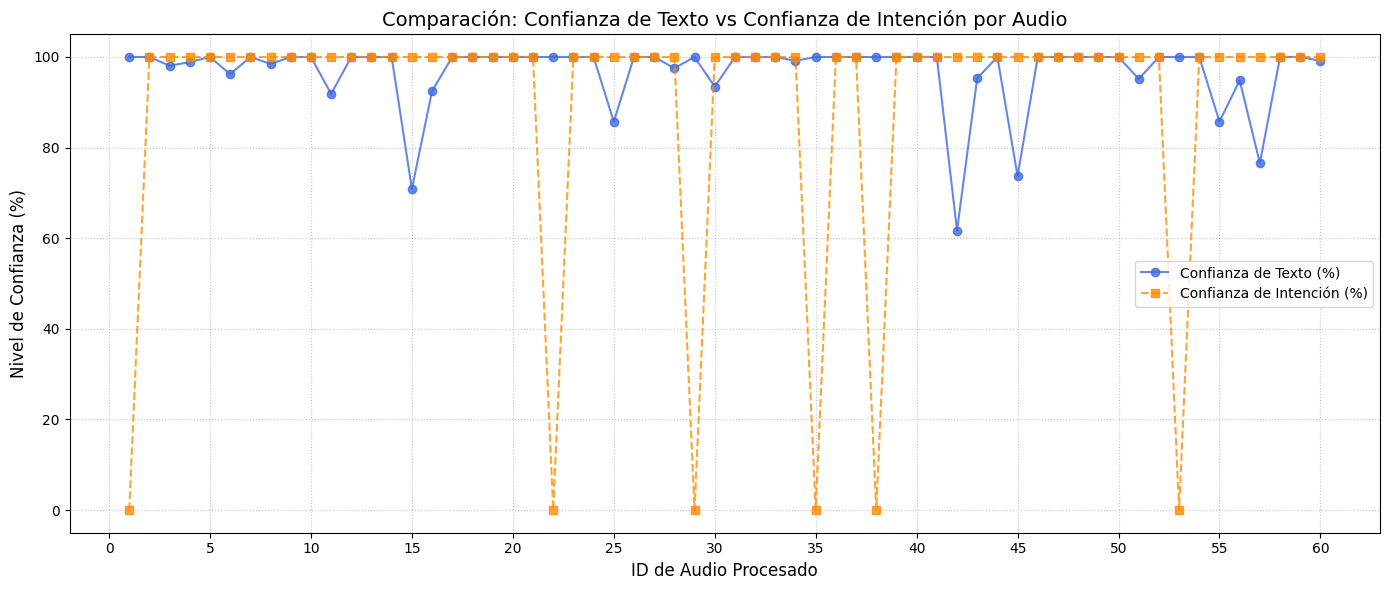

In [9]:
#ELEMENTO GRAFICO DE GENERACION - NO OBLIGATORIO

import matplotlib.pyplot as plt
import numpy as np

# Usando los datos generados en la celda anterior
muestras = np.arange(1, len(resultados_texto) + 1)

fig, ax = plt.subplots(figsize=(14, 6))

# Graficar Confianza de Texto
ax.plot(muestras, resultados_texto, marker='o', linestyle='-', label='Confianza de Texto (%)', color='royalblue', alpha=0.8)

# Graficar Confianza de Intención
ax.plot(muestras, resultados_intencion, marker='s', linestyle='--', label='Confianza de Intención (%)', color='darkorange', alpha=0.8)

ax.set_title('Comparación: Confianza de Texto vs Confianza de Intención por Audio', fontsize=14)
ax.set_xlabel('ID de Audio Procesado', fontsize=12)
ax.set_ylabel('Nivel de Confianza (%)', fontsize=12)
ax.set_xticks(np.arange(0, len(resultados_texto) + 1, 5))
ax.legend()
ax.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

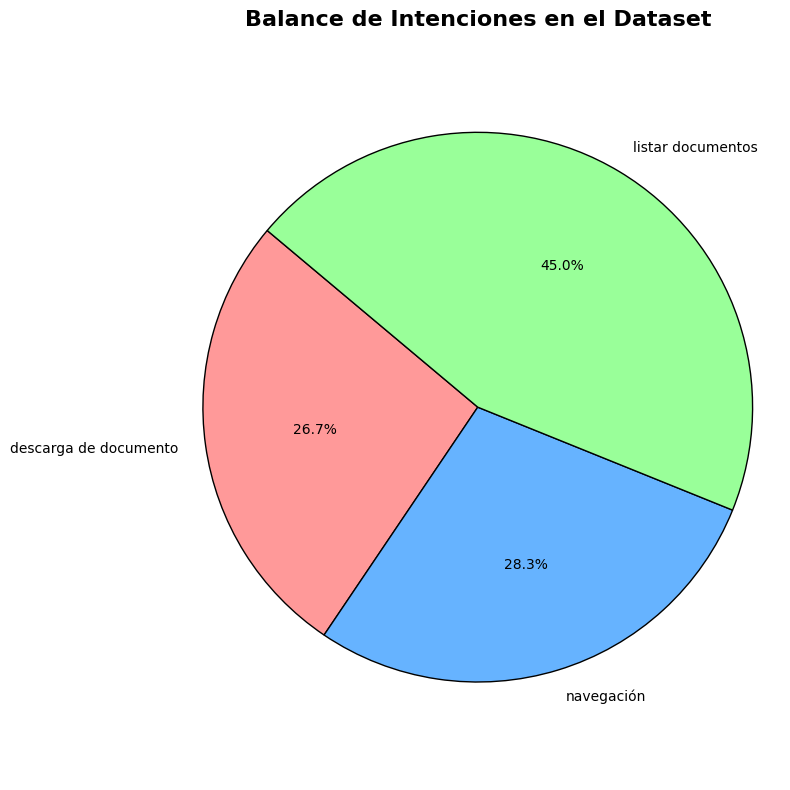

In [10]:
#ELEMENTO GRAFICO DE GENERACION - NO OBLIGATORIO

import matplotlib.pyplot as plt
from collections import Counter

def graficar_balance_dataset(intenciones):
    """
    Grafica un diagrama de pastel (torta) mostrando el balance de clases (intenciones) en el dataset.
    """
    if not intenciones:
        print("No hay datos de intenciones para graficar.")
        return

    conteo = Counter(intenciones)
    etiquetas = list(conteo.keys())
    valores = list(conteo.values())

    fig, ax = plt.subplots(figsize=(8, 8))

    # Colores personalizados (opcional)
    colores = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0']

    # Crear el gráfico de torta
    ax.pie(valores, labels=etiquetas, autopct='%1.1f%%', startangle=140, colors=colores[:len(etiquetas)],
           wedgeprops={'edgecolor': 'black', 'linewidth': 1})

    # Asegurar que el gráfico sea un círculo perfecto
    ax.axis('equal')

    plt.title('Balance de Intenciones en el Dataset', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Llamar a la función usando la lista de intenciones esperadas (intenciones_list) obtenida previamente
graficar_balance_dataset(intenciones_list)

Total registros originales: 60
Total registros balanceados: 81



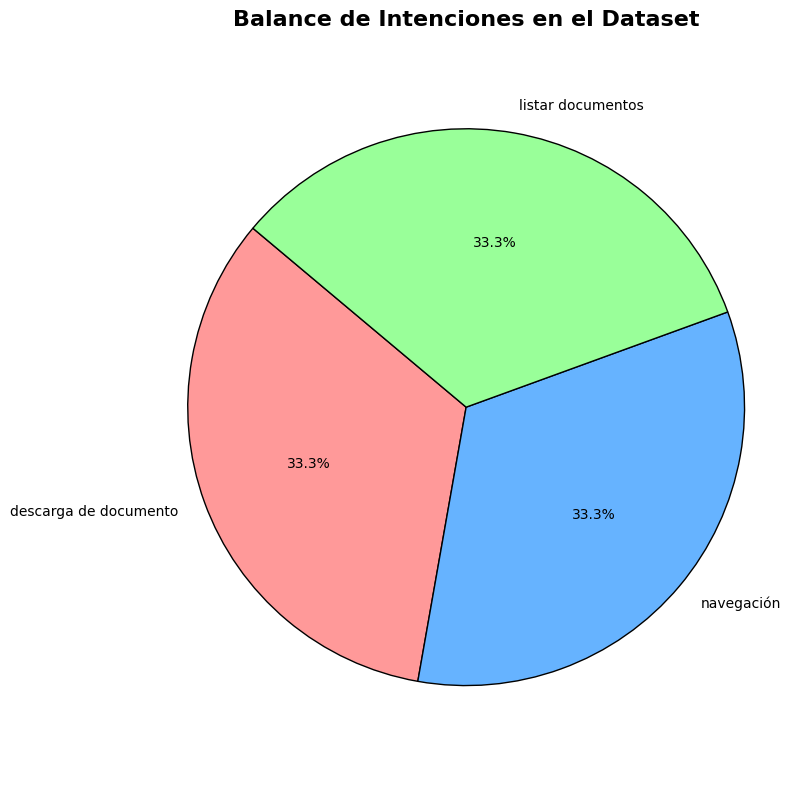

Archivo 'transcripcionesXindice_balanceado.json' exportado exitosamente.


In [12]:
#ELEMENTO GRAFICO DE GENERACION - NO OBLIGATORIO

import random
import copy
import json

def augment_text(texto: str) -> str:
    """
    Aplica una variación básica al texto para data augmentation.
    """
    prefijos = ["por favor ", "necesito que ", "quisiera ", "podrias ", "muestrame ", ""]
    sufijos = [" ya", " ahora mismo", " rapido", " por favor", " en pantalla", ""]

    prefijo = random.choice(prefijos)
    sufijo = random.choice(sufijos)

    # Evitar redundancias simples
    if "por favor" in texto.lower() and "por favor" in prefijo:
        prefijo = ""

    texto_aumentado = f"{prefijo}{texto}{sufijo}".strip()
    # Limpiar dobles espacios por si acaso
    texto_aumentado = " ".join(texto_aumentado.split())
    return texto_aumentado

def balancear_dataset_augmentation(dataset_ordenes: dict, catalogos: dict) -> tuple:
    """
    Realiza data augmentation para balancear las intenciones (LD, DD, N)
    igualando la cantidad de registros a la clase mayoritaria.
    """
    # 1. Agrupar por intención ID
    grupos = {}
    for idx, data in dataset_ordenes.items():
        intencion_id = str(data.get("intencion", "Desconocida"))
        if intencion_id not in grupos:
            grupos[intencion_id] = []
        grupos[intencion_id].append((idx, data))

    # 2. Encontrar el tamaño de la clase mayoritaria
    max_size = max(len(items) for items in grupos.values())

    # 3. Crear copia del dataset para no alterar el original
    dataset_balanceado = copy.deepcopy(dataset_ordenes)

    # 4. Determinar el siguiente ID disponible (ej. 061, 062...)
    indices_existentes = [int(k) for k in dataset_ordenes.keys() if k.isdigit()]
    next_idx = max(indices_existentes) + 1 if indices_existentes else 1

    # 5. Aumentar las clases minoritarias
    for intencion_id, items in grupos.items():
        num_aumentar = max_size - len(items)

        for _ in range(num_aumentar):
            # Elegir un registro aleatorio de la clase minoritaria
            orig_idx, orig_data = random.choice(items)

            # Generar el nuevo registro con data augmentation en el texto
            nuevo_data = copy.deepcopy(orig_data)
            nuevo_data["texto"] = augment_text(orig_data["texto"])

            if "texto_limpio" in nuevo_data:
                 nuevo_data["texto_limpio"] = augment_text(orig_data["texto_limpio"])

            # Guardar con nuevo ID
            nuevo_idx_str = f"{next_idx:03d}"
            dataset_balanceado[nuevo_idx_str] = nuevo_data
            next_idx += 1

    return dataset_balanceado

# --- EJECUCIÓN Y GRAFICACIÓN ---
ordenes_originales = json_data.get("dataSetOrdenes", {})
catalogos = json_data.get("catalogos", {})

# Generar el dataset balanceado
ordenes_balanceadas = balancear_dataset_augmentation(ordenes_originales, catalogos)

print(f"Total registros originales: {len(ordenes_originales)}")
print(f"Total registros balanceados: {len(ordenes_balanceadas)}\n")

# Extraer la nueva lista de intenciones mapeadas para graficar
nuevas_intenciones_list = []
for idx, data in ordenes_balanceadas.items():
    intencion_id = str(data.get("intencion", "Desconocida"))
    intencion_nombre = catalogos.get("intenciones", {}).get(intencion_id, intencion_id)
    nuevas_intenciones_list.append(intencion_nombre)

# Regraficar usando la función creada en la celda anterior
graficar_balance_dataset(nuevas_intenciones_list)

# --- EXPORTAR A JSON ---
# Crear el objeto final que contenga tanto los catálogos como el nuevo dataset balanceado
nuevo_json_export = copy.deepcopy(json_data)
nuevo_json_export["dataSetOrdenes"] = ordenes_balanceadas

# Guardar en archivo
with open("transcripcionesXindice_balanceado.json", "w", encoding="utf-8") as f:
    json.dump(nuevo_json_export, f, ensure_ascii=False, indent=4)

print("Archivo 'transcripcionesXindice_balanceado.json' exportado exitosamente.")


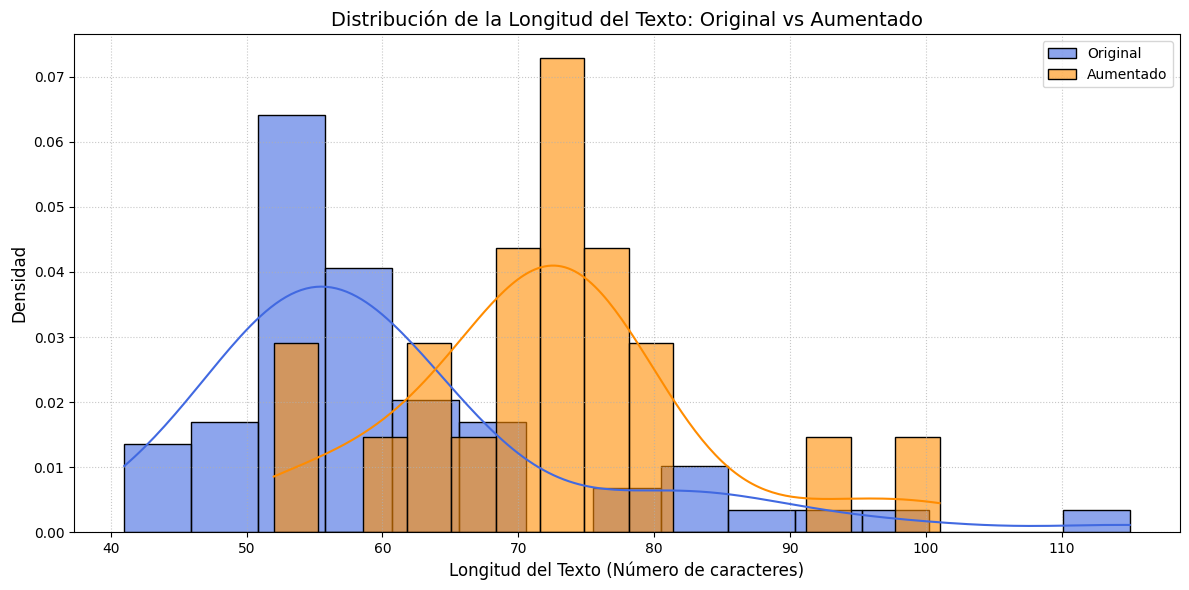

In [13]:
#ELEMENTO GRAFICO DE GENERACION - NO OBLIGATORIO

import matplotlib.pyplot as plt
import seaborn as sns

# Extraer las longitudes de los textos originales
original_lengths = [len(data['texto']) for idx, data in ordenes_originales.items()]

# Extraer las longitudes de los textos aumentados (los que se añadieron al dataset original)
augmented_lengths = [len(data['texto']) for idx, data in ordenes_balanceadas.items() if idx not in ordenes_originales]

# Configurar la gráfica
plt.figure(figsize=(12, 6))

# Dibujar histogramas con curvas de densidad
sns.histplot(original_lengths, color='royalblue', label='Original', kde=True, stat="density", bins=15, alpha=0.6)
sns.histplot(augmented_lengths, color='darkorange', label='Aumentado', kde=True, stat="density", bins=15, alpha=0.6)

# Personalizar el gráfico
plt.title('Distribución de la Longitud del Texto: Original vs Aumentado', fontsize=14)
plt.xlabel('Longitud del Texto (Número de caracteres)', fontsize=12)
plt.ylabel('Densidad', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

# Mostrar el gráfico
plt.tight_layout()
plt.show()